In [25]:
import pandas as pd

df_qol = pd.read_csv('quality_of_life.csv') 

# Define the weights for each factor
weights = {
    'stability': 0.15,
    'rights': 0.20,
    'health': 0.25,
    'safety': 0.10,
    'climate': 0.15,
    'costs': 0.15,
    'popularity': 0.10
}

# Ensure the relevant columns exist in df_QOL
# Replace column names with the actual column names in your dataset
df_qol['qol_index'] = (
    df_qol['stability'] * weights['stability'] +
    df_qol['rights'] * weights['rights'] +
    df_qol['health'] * weights['health'] +
    df_qol['safety'] * weights['safety'] +
    df_qol['climate'] * weights['climate'] +
    df_qol['costs'] * weights['costs'] +
    df_qol['popularity'] * weights['popularity']
)

# Display the updated DataFrame
df_qol.info()   
df_qol.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     137 non-null    object 
 1   stability   137 non-null    int64  
 2   rights      137 non-null    int64  
 3   health      137 non-null    int64  
 4   safety      137 non-null    int64  
 5   climate     137 non-null    int64  
 6   costs       137 non-null    int64  
 7   popularity  137 non-null    int64  
 8   qol_index   137 non-null    float64
dtypes: float64(1), int64(7), object(1)
memory usage: 9.8+ KB


,stability,rights,health,safety,climate,costs,popularity,qol_index
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,57.576642,50.686131,58.124088,76.781022,53.291971,52.343066,37.036496,60.531752
std,19.328706,25.142755,26.093284,21.791362,19.908674,11.612897,11.121263,13.145371
min,8.000000,7.000000,0.000000,4.000000,2.000000,23.000000,11.000000,29.400000
25%,46.000000,32.000000,42.000000,69.000000,43.000000,44.000000,31.000000,51.300000
50%,57.000000,45.000000,63.000000,85.000000,54.000000,54.000000,36.000000,60.750000
75%,72.000000,72.000000,80.000000,93.000000,67.000000,61.000000,42.000000,71.900000
max,93.000000,100.000000,100.000000,100.000000,95.000000,76.000000,73.000000,84.950000


In [ ]:
df_WHR = pd.read_excel('world-happiness-2022.xls')
df_WHR.dropna(inplace=True)
df_WHR.drop(columns=['RANK', 'Whisker-high', 'Whisker-low'], inplace=True)
df_WHR.columns = ['country', 'happiness', 'dystopia', 'log_gdp', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'perceptions_of_corruption']
# remove * from country names
df_WHR['country'] = df_WHR['country'].str.replace('*', '', regex=False)
df_WHR.info()
df_WHR.head(6)

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 0 to 145
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    146 non-null    object 
 1   happiness                  146 non-null    float64
 2   dystopia                   146 non-null    float64
 3   log_gdp                    146 non-null    float64
 4   social_support             146 non-null    float64
 5   healthy_life_expectancy    146 non-null    float64
 6   freedom                    146 non-null    float64
 7   generosity                 146 non-null    float64
 8   perceptions_of_corruption  146 non-null    float64
dtypes: float64(8), object(1)
memory usage: 11.4+ KB


,country,happiness,dystopia,log_gdp,social_support,healthy_life_expectancy,freedom,generosity,perceptions_of_corruption
0,Finland,7.8210,2.518052,1.891628,1.258108,0.775206,0.735590,0.108733,0.533658
1,Denmark,7.6362,2.225632,1.952595,1.242681,0.776644,0.718918,0.187626,0.532079
2,Iceland,7.5575,2.320185,1.935726,1.319914,0.802622,0.718194,0.269616,0.191204
3,Switzerland,7.5116,2.152746,2.025970,1.226074,0.822048,0.676947,0.146822,0.461004
4,Netherlands,7.4149,2.136937,1.944578,1.205848,0.786738,0.650682,0.271076,0.419083
5,Luxembourg,7.4040,2.041680,2.209395,1.154525,0.790365,0.699728,0.120203,0.388120


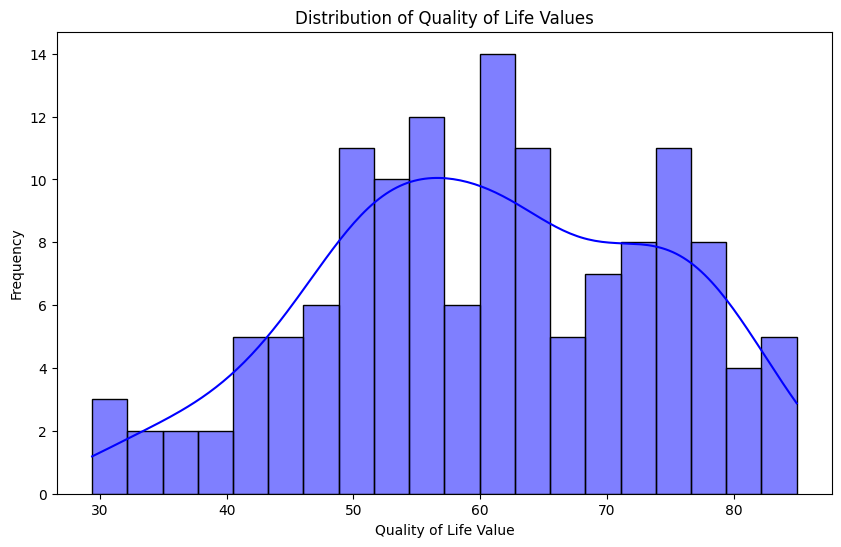

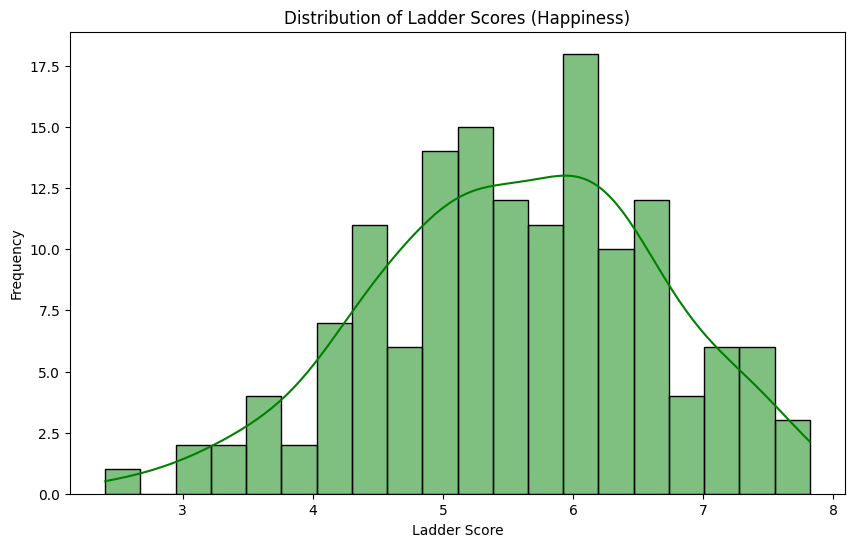

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of Quality of Life values
plt.figure(figsize=(10, 6))
sns.histplot(df_qol['qol_index'], kde=True, bins=20, color='blue')
plt.title('Distribution of Quality of Life Values')
plt.xlabel('Quality of Life Value')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of Ladder Score (Happiness)
plt.figure(figsize=(10, 6))
sns.histplot(df_WHR['happiness'], kde=True, bins=20, color='green')
plt.title('Distribution of Ladder Scores (Happiness)')
plt.xlabel('Ladder Score')
plt.ylabel('Frequency')
plt.show()


Correlation Matrix for Quality of Life Dataset:
            stability    rights    health    safety   climate     costs  \
stability    1.000000  0.846775  0.693995  0.594684 -0.435798 -0.362504   
rights       0.846775  1.000000  0.761785  0.619760 -0.459522 -0.507847   
health       0.693995  0.761785  1.000000  0.665243 -0.435529 -0.365072   
safety       0.594684  0.619760  0.665243  1.000000 -0.360111 -0.227878   
climate     -0.435798 -0.459522 -0.435529 -0.360111  1.000000  0.089632   
costs       -0.362504 -0.507847 -0.365072 -0.227878  0.089632  1.000000   
popularity   0.047140  0.120268  0.055298  0.120455  0.066271 -0.292222   
qol_index    0.844400  0.888554  0.908358  0.762322 -0.303067 -0.365010   

            popularity  qol_index  
stability     0.047140   0.844400  
rights        0.120268   0.888554  
health        0.055298   0.908358  
safety        0.120455   0.762322  
climate       0.066271  -0.303067  
costs        -0.292222  -0.365010  
popularity    1.000000 

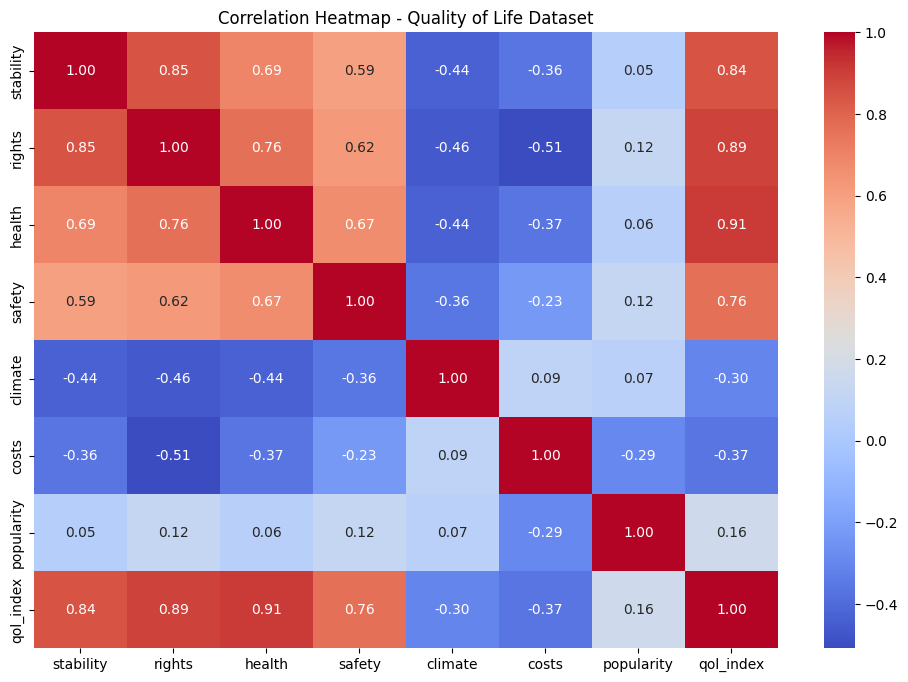

In [ ]:
# Select only numeric columns from the Quality of Life dataset
numeric_df_QOL = df_qol.select_dtypes(include=['number'])

# Correlation matrix for Quality of Life dataset
print("\nCorrelation Matrix for Quality of Life Dataset:")
print(numeric_df_QOL.corr())

# Heatmap of correlations for Quality of Life dataset
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_QOL.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Quality of Life Dataset')
plt.show()

In [26]:
df = pd.read_excel('world-happiness-2022.xls')
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   RANK                                        147 non-null    int64  
 1   Country                                     147 non-null    object 
 2   Happiness score                             146 non-null    float64
 3   Whisker-high                                146 non-null    float64
 4   Whisker-low                                 146 non-null    float64
 5   Dystopia (1.83) + residual                  146 non-null    float64
 6   Explained by: GDP per capita                146 non-null    float64
 7   Explained by: Social support                146 non-null    float64
 8   Explained by: Healthy life expectancy       146 non-null    float64
 9   Explained by: Freedom to make life choices  146 non-null    float64
 10  Explained by: 

,RANK,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
count,147.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,74.000000,5.553575,5.673613,5.433538,1.831807,1.410429,0.905834,0.586146,0.517225,0.147372,0.154758
std,42.579338,1.086814,1.065649,1.109374,0.534971,0.421655,0.280123,0.176352,0.145833,0.082763,0.127522
min,1.000000,2.403800,2.468731,2.338869,0.187416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.500000,4.888550,5.006018,4.754731,1.555475,1.095578,0.732114,0.462953,0.440506,0.088723,0.068087
50%,74.000000,5.568700,5.680081,5.453245,1.894558,1.445134,0.957799,0.621445,0.543633,0.132417,0.119459
75%,110.500000,6.305025,6.448932,6.189783,2.152897,1.785087,1.114658,0.720065,0.625763,0.197554,0.198213
max,147.000000,7.821000,7.886425,7.755575,2.844388,2.209395,1.319914,0.941829,0.740039,0.467926,0.586828


In [ ]:
import logging
import pandas as pd
from sqlalchemy import create_engine
# from dynaconf import Dynaconf

log = logging.getLogger(__name__)
log.setLevel(logging.WARNING)

class ETLProcessor:
    def __init__(self, qol_path: str, whr_path: str, engine):
        self.qol_path = qol_path
        self.whr_path = whr_path
        self.engine = engine
        
    def extract(self):
        log.info("Extracting data...")
        df_qol = pd.read_csv(self.qol_path)
        log.info(f"Extracted Quality of Life data: {df_qol.shape[0]} rows")
        
        df_whr = pd.read_excel(self.whr_path)
        log.info(f"Extracted World Happiness Report data: {df_whr.shape[0]} rows")
        return df_qol, df_whr
    
    def transform(self, df_qol, df_whr):
        log.info("Transforming data...")
        
        # transform Quality of Life data
        # Define the weights for each factor
        weights = {
            'stability': 0.15,
            'rights': 0.20,
            'health': 0.25,
            'safety': 0.10,
            'climate': 0.15,
            'costs': 0.15,
            'popularity': 0.10
        }

        df_qol['qol_index'] = (
            df_qol['stability'] * weights['stability'] +
            df_qol['rights'] * weights['rights'] +
            df_qol['health'] * weights['health'] +
            df_qol['safety'] * weights['safety'] +
            df_qol['climate'] * weights['climate'] +
            df_qol['costs'] * weights['costs'] +
            df_qol['popularity'] * weights['popularity']
        )
        log.info("Transformed Quality of Life data adding qol_index")
            
        # transform World Happiness Report data
        df_whr.dropna(inplace=True)
        df_whr.drop(columns=['RANK', 'Whisker-high', 'Whisker-low'], inplace=True)
        df_whr.columns = ['country_name', 'happiness', 'dystopia', 'log_gdp', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'perceptions_of_corruption']
        df_whr['country_name'] = df_whr['country_name'].str.replace('*', '', regex=False)    
        
        return df_qol, df_whr
    
    def load(self, df_qol, df_whr):
        log.info("Loading data into the database...")

        # Combine country names from both datasets
        countries_qol = df_qol['country_name'].unique()
        countries_whr = df_whr['country_name'].unique()
        all_countries = pd.DataFrame(
            {'country_name': pd.unique(pd.concat([pd.Series(countries_qol), pd.Series(countries_whr)]))}
        )

        # Load countries into the 'country' table
        all_countries.to_sql('country', con=self.engine, if_exists='replace', index=False)
        log.info(f"Loaded {len(all_countries)} countries into the 'country' table.")

        # Verify the data was loaded
        loaded_countries = pd.read_sql("SELECT * FROM country", con=self.engine)
        log.info(f"Countries in the database:\n{loaded_countries}")
        print(loaded_countries)
    